In [1]:
import pandas as pd

df = pd.read_csv("../data/telco_churn.csv")

print(df.shape)
print(df.info())
print(df["Churn"].value_counts())
print(df.isna().sum())

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


In [2]:
print(df["TotalCharges"].dtype)

print(df["TotalCharges"].head())

print(df["TotalCharges"].describe())

str
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str
count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object


In [ ]:
#  1. Distribution de la cible
print(
    round(
        df['Churn'].value_counts(normalize=True)*100,
        2
    )
)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [ ]:
# 2. Churn par type de contrat
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
# 3. Statistiques numériques
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [3]:
# 4. Corrélation

# D'abord convertir la cible
df["ChurnBinary"] = (
    df["Churn"].map({'No':0, 'Yes':1})
)

In [4]:
num_cols = [
    "tenure",
    "MonthlyCharges",
    "ChurnBinary"
]


In [5]:
print(df[num_cols].corr())

                  tenure  MonthlyCharges  ChurnBinary
tenure          1.000000        0.247900    -0.352229
MonthlyCharges  0.247900        1.000000     0.193356
ChurnBinary    -0.352229        0.193356     1.000000


Matplotlib is building the font cache; this may take a moment.


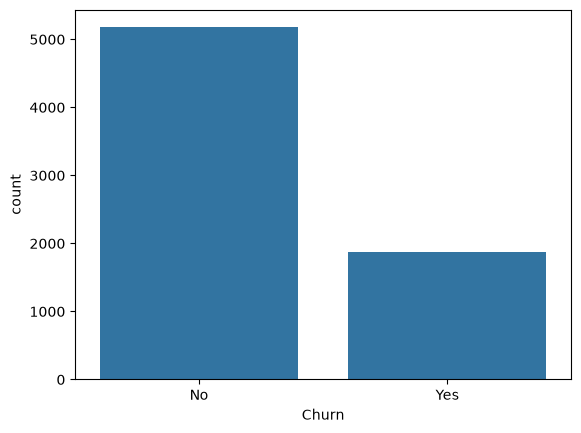

In [ ]:
# 5. Visualisations
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Churn")
plt.show()

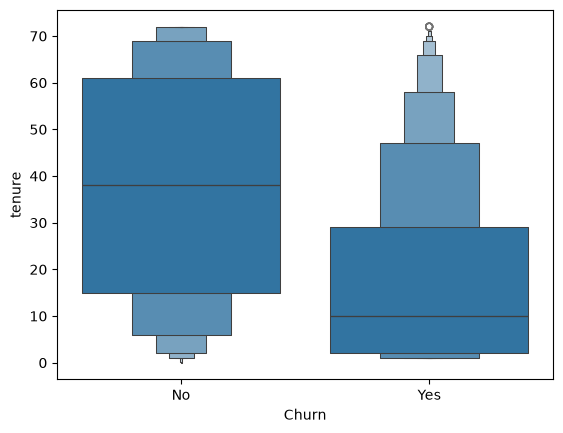

In [11]:
# Ancienneté
sns.boxenplot(
    data=df,
    x = "Churn",
    y = "tenure"
)
plt.show()

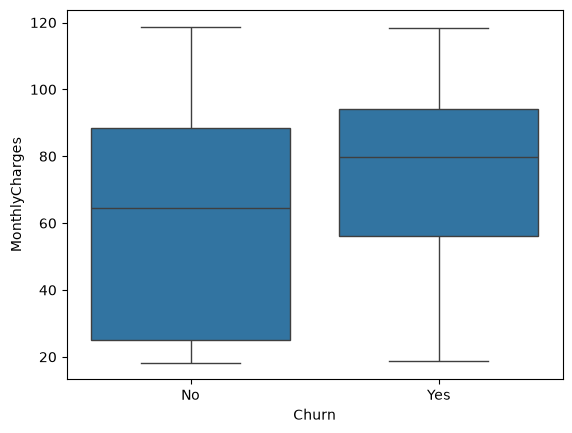

In [12]:
# Facturation
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)
plt.show()

In [13]:
df['Churn'].value_counts(normalize=True)

pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Interprétation métier

Les clients ayant un contrat mensuel quittent beaucoup plus souvent l'opérateur.

Month-to-month
    ↓
42.7 % de churn

Two year
    ↓
2.8 % de churn

In [16]:
# Ancienneté
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


Ancienneté (tenure)

| Churn | Ancienneté moyenne |
| ----- | ------------------ |
| No    | 37.6 mois          |
| Yes   | 18.0 mois          |

Conclusion

Les clients qui quittent l'opérateur sont généralement beaucoup plus récents.

Client récent
      ↓
Risque de churn élevé

Client ancien
      ↓
Risque de churn faible

La médiane est encore plus parlante :

Churn	Médiane
No	38 mois
Yes	10 mois

Donc la moitié des clients qui partent ont moins de 10 mois d'ancienneté.

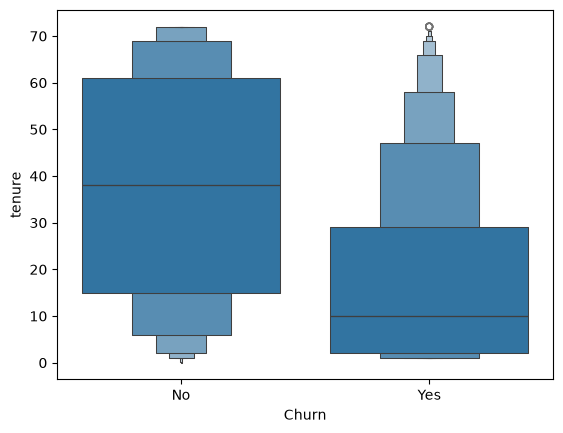

In [17]:
sns.boxenplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.show()

Identifier les variables les plus liées au churn

In [18]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


Facturation mensuelle

| Churn | Facture moyenne |
| ----- | --------------- |
| No    | 61.27           |
| Yes   | 74.44           |

Conclusion

Les clients qui paient plus cher quittent davantage.

Cela peut signifier :

- prix perçu comme élevé
- services premium insatisfaisants
- concurrence moins chère

### Premiers facteurs identifiés:

| Variable       | Impact    |
| -------------- | --------- |
| Contract       | Très fort |
| Tenure         | Très fort |
| MonthlyCharges | Fort      |
